In [10]:
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

In [11]:
# Auto-detect workspace root so this works no matter where the kernel starts
target_rel = Path("2_Train_FaceRecognition_with_ML") / "data" / "Dataset.csv"
WORKSPACE = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / target_rel).exists():
        WORKSPACE = p
        break

if WORKSPACE is None:
    raise FileNotFoundError(
        f"Could not find {target_rel}. Current working dir: {Path.cwd()}"
    )

# Base folders
BASE = WORKSPACE / "2_Train_FaceRecognition_with_ML" / "data"
CSV_PATH = BASE / "Dataset.csv"
SRC_ROOT = BASE / "Original Images" / "Original Images"
DST_ROOT = BASE / "Faces" / "Faces"

# Ensure output folder exists
DST_ROOT.mkdir(parents=True, exist_ok=True)

# Preprocessing params
OUT_SIZE = (160, 160)   # final size for each face crop
MARGIN = 0.25           # 25% padding around detected face
MIN_FACE = 40           # ignore very tiny detections

print("CWD:", Path.cwd())
print("Workspace:", WORKSPACE)
print("CSV exists:", CSV_PATH.exists(), CSV_PATH)

CWD: c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML
Workspace: c:\Users\schha\attendify_scratch
CSV exists: True c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\Dataset.csv


In [12]:
df = pd.read_csv(CSV_PATH)
print("Total rows:", len(df))
display(df.head())

Total rows: 2562


,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish
4,Hrithik Roshan_35.jpg,Hrithik Roshan


Processing 2562 images...


100%|██████████| 2562/2562 [06:48<00:00,  6.27it/s]

Saved: 2475/2562
Failed: 87
Failure log: c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\crop_failures.csv


reason
no_face_detected    87
Name: count, dtype: int64

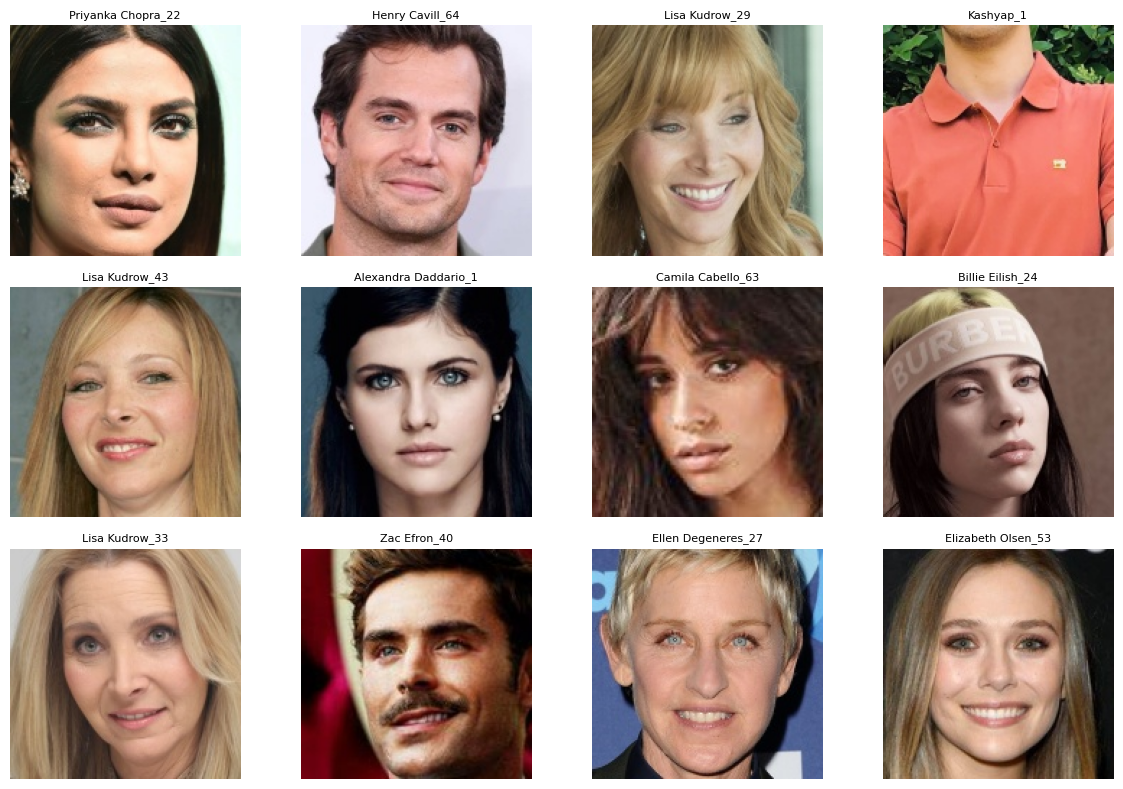

In [13]:
# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
 )
if face_cascade.empty():
    raise RuntimeError("Failed to load Haar cascade detector.")

def detect_largest_face(img_bgr, min_face=40):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(min_face, min_face),
    )
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    return x, y, w, h

def make_square_bbox(x, y, w, h, img_w, img_h, margin=0.25):
    cx = x + w / 2
    cy = y + h / 2
    side = max(w, h) * (1 + margin)

    x1 = int(round(cx - side / 2))
    y1 = int(round(cy - side / 2))
    x2 = int(round(cx + side / 2))
    y2 = int(round(cy + side / 2))

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    side2 = min(x2 - x1, y2 - y1)
    if side2 <= 0:
        return None
    x2 = x1 + side2
    y2 = y1 + side2
    return x1, y1, x2, y2

# ---- Run settings ----
RUN_TEST_BATCH = False
TEST_BATCH_SIZE = 100  # used only when RUN_TEST_BATCH is True

run_df = df.head(TEST_BATCH_SIZE).copy() if RUN_TEST_BATCH else df.copy()
print(f"Processing {len(run_df)} images...")

saved = 0
failed = []

for _, row in tqdm(run_df.iterrows(), total=len(run_df)):
    img_id = row["id"]
    label = row["label"]

    src_path = SRC_ROOT / label / img_id
    dst_path = DST_ROOT / img_id

    if not src_path.exists():
        failed.append((img_id, label, "missing_file"))
        continue

    img = cv2.imread(str(src_path))
    if img is None:
        failed.append((img_id, label, "imread_failed"))
        continue

    det = detect_largest_face(img, min_face=MIN_FACE)
    if det is None:
        failed.append((img_id, label, "no_face_detected"))
        continue

    x, y, w, h = det
    box = make_square_bbox(x, y, w, h, img.shape[1], img.shape[0], margin=MARGIN)
    if box is None:
        failed.append((img_id, label, "bad_bbox"))
        continue

    x1, y1, x2, y2 = box
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        failed.append((img_id, label, "empty_crop"))
        continue

    crop = cv2.resize(crop, OUT_SIZE, interpolation=cv2.INTER_AREA)
    ok = cv2.imwrite(str(dst_path), crop)
    if not ok:
        failed.append((img_id, label, "imwrite_failed"))
        continue

    saved += 1

print(f"Saved: {saved}/{len(run_df)}")
print(f"Failed: {len(failed)}")

if failed:
    fail_df = pd.DataFrame(failed, columns=["id", "label", "reason"])
    fail_path = BASE / ("crop_failures_test.csv" if RUN_TEST_BATCH else "crop_failures.csv")
    fail_df.to_csv(fail_path, index=False)
    print("Failure log:", fail_path)
    display(fail_df["reason"].value_counts())

# Quick visual check
saved_files = list(DST_ROOT.glob("*.jpg"))
if saved_files:
    n = min(12, len(saved_files))
    picks = random.sample(saved_files, n)
    plt.figure(figsize=(12, 8))
    for i, p in enumerate(picks, 1):
        im = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        plt.subplot(3, 4, i)
        plt.imshow(im)
        plt.title(p.stem[:20], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()